#### Breast Cancer Detection

1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

2. Load the dataset

In [4]:
df = pd.read_csv('breast cancer.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (569, 32)

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


3. Data Preprocessing

In [5]:
# Drop 'id' column (not a feature)
df.drop(columns=['id'], inplace=True)

# Check missing values
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Encode target: M → 1 (Malignant), B → 0 (Benign)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # B=0, M=1
print("\nClass distribution:")
print(df['diagnosis'].value_counts().rename({1:'Malignant', 0:'Benign'}))

# Features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nPreprocessing done ✓")

Missing values:
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Duplicates: 0

Class distribution:
diagnosis
Benign       357
Malignan

4. Find Best k

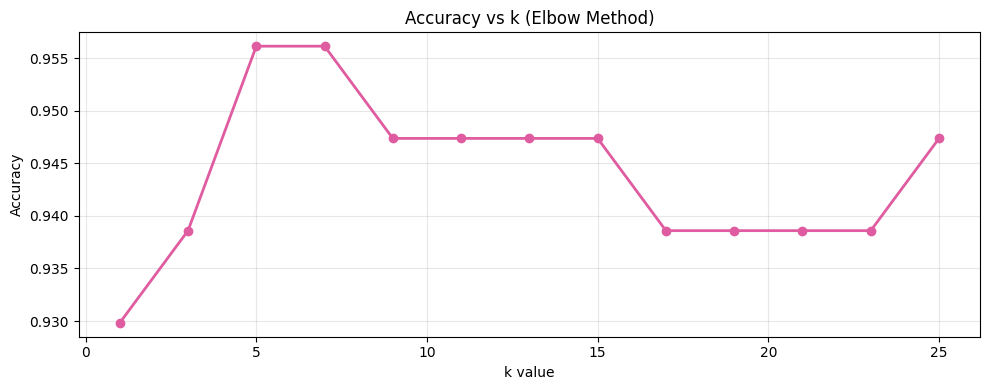

Best k: 5  →  Accuracy: 95.61%


In [6]:
k_values = range(1, 26, 2)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(10, 4))
plt.plot(k_values, accuracies, marker='o', color='#e05ca0', linewidth=2)
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k (Elbow Method)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_values)[accuracies.index(max(accuracies))]
print(f"Best k: {best_k}  →  Accuracy: {max(accuracies)*100:.2f}%")

5. Train Final Model

In [7]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"Model trained with k = {best_k} ✓")

Model trained with k = 5 ✓


6. Evaluate Model

Accuracy : 95.61 %
Precision: 97.44 %
Recall   : 90.48 %
F1 Score : 93.83 %

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



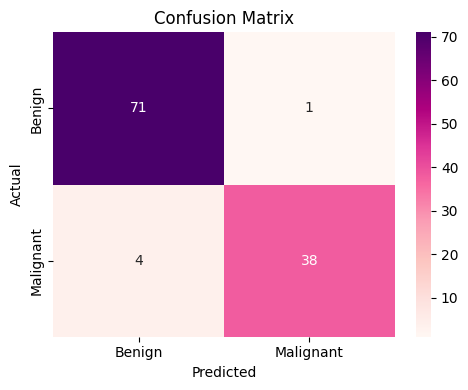

In [8]:
print("Accuracy :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

7. Test with Custom Samples

In [9]:
# Test on a few rows from the test set
for i in [0, 5, 10, 20, 30]:
    pred  = knn.predict(X_test[i].reshape(1, -1))[0]
    actual = y_test.iloc[i]
    print(f"Sample {i:2d} → Predicted: {'Malignant' if pred==1 else 'Benign':10s} | Actual: {'Malignant' if actual==1 else 'Benign'}")

Sample  0 → Predicted: Benign     | Actual: Benign
Sample  5 → Predicted: Benign     | Actual: Benign
Sample 10 → Predicted: Malignant  | Actual: Malignant
Sample 20 → Predicted: Benign     | Actual: Benign
Sample 30 → Predicted: Malignant  | Actual: Malignant


8. Saving Model

In [10]:
import joblib

joblib.dump(knn, 'knn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved: knn_model.pkl and scaler.pkl ✓")

Saved: knn_model.pkl and scaler.pkl ✓
